In [ ]:
import pandas as pd
import numpy as np
all_df_of_close_data = pd.read_csv('data/all_df_of_close_data.csv')

# month variable
all_df_of_close_data['transaction_month'] = pd.DatetimeIndex(all_df_of_close_data['transactionDate']).month

# recession dummy from https://fred.stlouisfed.org/release?rid=242
recession_dummy = pd.read_csv('data/recession_dummy/daily,_7-day.csv')
recession_dummy['USRECD'] = recession_dummy['USRECD'].astype('int8')
all_df_of_close_data = all_df_of_close_data.merge(recession_dummy,
                                                  left_on='transactionDate',
                                                  right_on='observation_date',
                                                  how="left").drop(columns=['observation_date'])

# count of fillings per person
# clean names becouse no id exported
all_df_of_close_data['reportingOwner.name'] = (all_df_of_close_data['reportingOwner.name']
             .str.replace(r'[^A-Za-z ]+', '', regex=True)
             .str.replace(r'\s+', ' ', regex=True)
             .str.strip()
             .str.upper())


count_trades_tbl = (all_df_of_close_data
       .groupby('reportingOwner.name')['issuer.tradingSymbol']
       .count()
       .rename('count')
       .reset_index())

all_df_of_close_data = all_df_of_close_data.merge(
    count_trades_tbl.rename(columns={"count": "filing_count_reportingOwner.name"}),
    on="reportingOwner.name", how="left"
)

# Clusterbuys in past 14 days
df = all_df_of_close_data.copy()
df['transactionDate'] = pd.to_datetime(df['transactionDate'], errors='coerce')

# calculate daily fillings of ticker
daily = (df.groupby(['issuer.tradingSymbol', 'transactionDate']).size()
           .rename('n').reset_index())

# rolling count for past 14 days of fillings for this ticker
roll = (daily.set_index('transactionDate')
              .groupby('issuer.tradingSymbol')['n']
              .rolling('14D').sum()
              .rename('trades_14d')
              .reset_index())

df = df.merge(roll, on=['issuer.tradingSymbol', 'transactionDate'], how='left')

all_df_of_close_data = df

# high price dummy
all_df_of_close_data['high_price'] = (all_df_of_close_data['0'] > all_df_of_close_data['0'].median()).astype('int8')

In [103]:
import pandas as pd
all_df_of_close_data = pd.read_csv('data/all_df_of_close_data.csv')



MemoryError: Unable to allocate 396. MiB for an array with shape (368, 141056) and data type float64

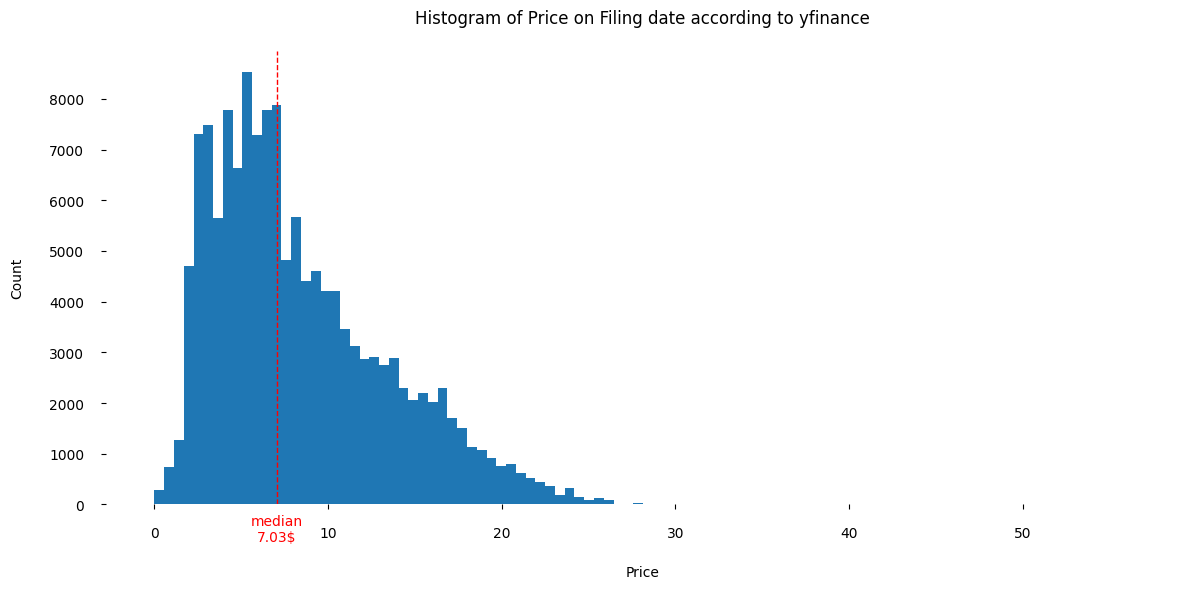

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.hist(all_df_of_close_data['0'], bins=100)
ax.set_title('Histogram of Price on Filing date according to yfinance')
ax.set_xlabel('Price')
ax.set_ylabel('Count')

# Spines aus
for s in ax.spines.values():
    s.set_visible(False)

ax.axvline(7.03, linestyle="--", lw=1, c="red")
ax.text(7.03, ax.get_ylim()[1]*-0.02, "median7.03$",
        va="top", ha="center", color="red")

plt.tight_layout()
plt.show()


In [104]:
all_df_of_close_data

,Unnamed: 0.1,Unnamed: 0,issuer.name,issuer.tradingSymbol,reportingOwner.name,transactionDate,amounts.shares,amounts.pricePerShare,postTransactionAmounts.sharesOwnedFollowingTransaction,ownershipNature.directOrIndirectOwnership,...,356,357,358,359,360,361,362,363,364,high_price
0,0,2735,ABBOTT LABORATORIES,ABT,TILTON GLENN F,2009-02-25,2000.0,53.63,10647.0,D,...,18.676229,18.730982,18.806242,18.604395,18.604395,18.604395,18.611233,18.464115,18.587284,1
1,1,2736,SIERRA BANCORP,BSRR,Scearcy Lynda,2009-02-26,200.0,6.25,3518.0,D,...,6.398380,6.411205,6.500963,6.500963,6.500963,6.500963,6.449671,6.507371,6.494549,0
2,2,2737,SIERRA BANCORP,BSRR,Scearcy Lynda,2009-02-26,200.0,6.50,3718.0,D,...,6.398380,6.411205,6.500963,6.500963,6.500963,6.500963,6.449671,6.507371,6.494549,0
3,3,2745,"ENSIGN GROUP, INC",ENSG,Nackel John G.,2009-02-27,2000.0,13.75,8000.0,D,...,4.073599,4.127295,4.127295,4.127295,3.931201,3.963884,3.952211,3.949878,3.889182,0
4,4,2771,CALPINE CORP,CPN,"LSP Cal Holdings II, LLC",2009-02-25,83340.0,5.25,17616711.0,D,...,11.400000,11.300000,11.290000,11.350000,11.350000,11.350000,11.460000,11.310000,11.240000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141051,237350,408025,"MainStreet Bancshares, Inc.",MNSB,ECHLOV RUSSELL,2023-07-31,100.0,23.81,2446.0,D,...,16.256369,16.217241,16.706301,16.344395,16.344395,16.344395,16.373741,16.227022,16.090086,1
141052,237351,408026,flooidCX Corp.,FLCX,Danzik Dennis M,2023-07-28,100.0,4.08,66670.0,D,...,1.100000,1.100000,1.100000,1.100000,1.100000,1.100000,1.100000,1.100000,1.100000,0
141053,237352,408027,AMES NATIONAL CORP,ATLO,Cassabaum Michelle R,2023-07-31,164.0,19.64,4737.0,D,...,17.029333,17.278076,17.498119,18.005171,18.397419,18.397419,18.397419,18.053009,17.517252,1
141054,237359,408034,Citizens Community Bancorp Inc.,CZWI,Bourget Kristina M,2023-07-28,306.0,10.30,16886.0,D,...,11.914000,12.041056,12.041056,12.041056,12.050830,12.158339,12.158339,12.774075,12.793622,1


In [107]:
all_df_of_close_data['holding_change_percent'] = (all_df_of_close_data['amounts.shares']/(all_df_of_close_data['postTransactionAmounts.sharesOwnedFollowingTransaction'] - (all_df_of_close_data['amounts.shares']+0.00005)))*100
all_df_of_close_data

,Unnamed: 0.1,Unnamed: 0,issuer.name,issuer.tradingSymbol,reportingOwner.name,transactionDate,amounts.shares,amounts.pricePerShare,postTransactionAmounts.sharesOwnedFollowingTransaction,ownershipNature.directOrIndirectOwnership,...,357,358,359,360,361,362,363,364,high_price,holding_change_percent
0,0,2735,ABBOTT LABORATORIES,ABT,TILTON GLENN F,2009-02-25,2000.0,53.63,10647.0,D,...,18.730982,18.806242,18.604395,18.604395,18.604395,18.611233,18.464115,18.587284,1,23.129409
1,1,2736,SIERRA BANCORP,BSRR,Scearcy Lynda,2009-02-26,200.0,6.25,3518.0,D,...,6.411205,6.500963,6.500963,6.500963,6.500963,6.449671,6.507371,6.494549,0,6.027728
2,2,2737,SIERRA BANCORP,BSRR,Scearcy Lynda,2009-02-26,200.0,6.50,3718.0,D,...,6.411205,6.500963,6.500963,6.500963,6.500963,6.449671,6.507371,6.494549,0,5.685048
3,3,2745,"ENSIGN GROUP, INC",ENSG,Nackel John G.,2009-02-27,2000.0,13.75,8000.0,D,...,4.127295,4.127295,4.127295,3.931201,3.963884,3.952211,3.949878,3.889182,0,33.333334
4,4,2771,CALPINE CORP,CPN,"LSP Cal Holdings II, LLC",2009-02-25,83340.0,5.25,17616711.0,D,...,11.300000,11.290000,11.350000,11.350000,11.350000,11.460000,11.310000,11.240000,0,0.475322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141051,237350,408025,"MainStreet Bancshares, Inc.",MNSB,ECHLOV RUSSELL,2023-07-31,100.0,23.81,2446.0,D,...,16.217241,16.706301,16.344395,16.344395,16.344395,16.373741,16.227022,16.090086,1,4.262575
141052,237351,408026,flooidCX Corp.,FLCX,Danzik Dennis M,2023-07-28,100.0,4.08,66670.0,D,...,1.100000,1.100000,1.100000,1.100000,1.100000,1.100000,1.100000,1.100000,0,0.150218
141053,237352,408027,AMES NATIONAL CORP,ATLO,Cassabaum Michelle R,2023-07-31,164.0,19.64,4737.0,D,...,17.278076,17.498119,18.005171,18.397419,18.397419,18.397419,18.053009,17.517252,1,3.586267
141054,237359,408034,Citizens Community Bancorp Inc.,CZWI,Bourget Kristina M,2023-07-28,306.0,10.30,16886.0,D,...,12.041056,12.041056,12.041056,12.050830,12.158339,12.158339,12.774075,12.793622,1,1.845597
